In [125]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor

In [39]:
np.random.seed(42)

data = pd.DataFrame({
    'size_sqft': np.random.randint(500, 3500, 100),
    'bedrooms': np.random.randint(1, 6, 100),
    'bathrooms': np.random.randint(1, 4, 100),
    'age': np.random.randint(0, 50, 100),
})

data['price'] = (data['size_sqft'] * 300) + (data['bedrooms'] * 10000) + \
                (data['bathrooms'] * 5000) - (data['age'] * 1000) + np.random.randint(-10000, 10000, 100)

print(data.head())

   size_sqft  bedrooms  bathrooms  age   price
0       1360         4          1   44  413599
1       1794         3          3    7  585708
2       1630         3          2   26  496051
3       1595         1          2   26  478479
4       2138         3          1   33  649788


Mean Squared Error: 34140968.25
Root Mean Squared Error: 5843.03
R^2 Score: 1.00


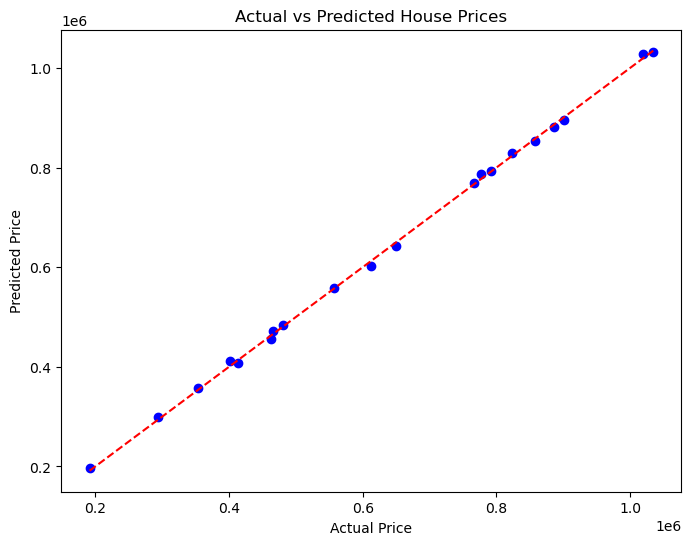

In [45]:
X = data[['size_sqft', 'bedrooms', 'bathrooms', 'age']]
y = data['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R^2 Score: {r2:.2f}")

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()


In [106]:
df = pd.read_csv('data.csv')
df

,price,bedrooms,sqft_living,sqft_lot,floors,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city
0,3.130000e+05,3,1340,7912,1.5,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline
1,2.384000e+06,5,3650,9050,2.0,4,5,3370,280,1921,0,709 W Blaine St,Seattle
2,3.420000e+05,3,1930,11947,1.0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent
3,4.200000e+05,3,2000,8030,1.0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue
4,5.500000e+05,4,1940,10500,1.0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,3.081667e+05,3,1510,6360,1.0,0,4,1510,0,1954,1979,501 N 143rd St,Seattle
4596,5.343333e+05,3,1460,7573,2.0,0,3,1460,0,1983,2009,14855 SE 10th Pl,Bellevue
4597,4.169042e+05,3,3010,7014,2.0,0,3,3010,0,2009,0,759 Ilwaco Pl NE,Renton
4598,2.034000e+05,4,2090,6630,1.0,0,3,1070,1020,1974,0,5148 S Creston St,Seattle


In [119]:
x = df[['yr_built', 'sqft_above', 'bedrooms']]
y = df['price']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

poly = PolynomialFeatures(degree=3)
x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.fit_transform(x_test)

model = LinearRegression()
model.fit(x_train_poly, y_train)

y_train_pred = model.predict(x_train_poly)
y_test_pred = model.predict(x_test_poly)

train_error = r2_score(y_train, y_train_pred)
test_error = r2_score(y_test, y_test_pred)

print(test_error, train_error)

0.051115313425318165 0.46208972885638655


In [124]:
gb_model = GradientBoostingRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
gb_model.fit(x_train, y_train)

y_train_pred_gb = gb_model.predict(x_train)
y_test_pred_gb = gb_model.predict(x_test)

train_error = r2_score(y_train, y_train_pred_gb)
test_error = r2_score(y_test, y_test_pred_gb)

print(test_error, train_error)

0.035573063411000194 0.7219218862906853


In [134]:
bag_model = BaggingRegressor(n_estimators=100, random_state=42)
bag_model.fit(x_train, y_train)

y_train_pred_bg = bag_model.predict(x_train)
y_test_pred_bg = bag_model.predict(x_test)

train_error = r2_score(y_train, y_train_pred_bg)
test_error = r2_score(y_test, y_test_pred_bg)

print(test_error, train_error)

0.02977735601204612 0.8799652719509263
